# Functions Practice

In [1]:
import pandas as pd
import seaborn as sns

Find the countries that had the top 3 largest GDP per capita figures for 2021. Create a seaborn FacetGrid showing the change in life expectancy over time for these three countries. Each individual figure in the facet grid will represent a single country.

In [2]:
gdp_le = pd.read_csv("../data/gdp_le.csv")
gdp_le.head(2)

,Country,Year,GDP_Per_Capita,Continent,Life_Expectancy
0,Afghanistan,2021,1517.016266,Asia,61.982
1,Afghanistan,2020,1968.341002,Asia,62.575


As part of the guided practice, you found the three countries with the highest gdp per capita for 2021 and then create a FacetGrid showing the change in life expectancy for these countries over time. The following code accomplishes this task:

In [3]:
gdp_le[gdp_le['Year'] == 2021].nlargest(3, 'GDP_Per_Capita')

,Country,Year,GDP_Per_Capita,Continent,Life_Expectancy
2857,Luxembourg,2021,115683.493708,Europe,82.597561
4364,Singapore,2021,107741.118436,Asia,83.092683
2285,Ireland,2021,102785.490239,Europe,82.353659


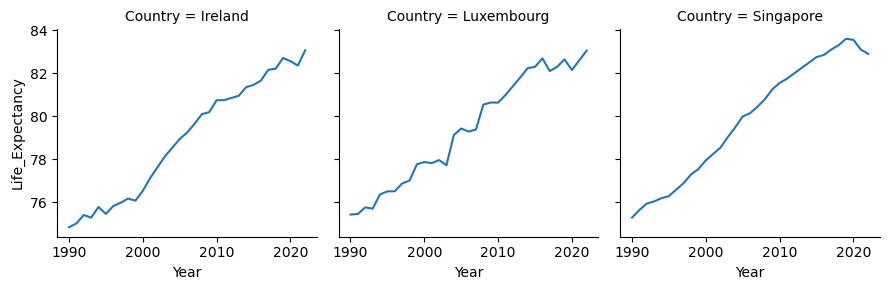

In [4]:
top_countries_df = gdp_le[gdp_le['Country'].isin(['Luxembourg', 'Singapore', 'Ireland'])]

g = sns.FacetGrid(data=top_countries_df, col='Country')
g.map(sns.lineplot, 'Year', 'Life_Expectancy');

In this exercise, we'll see how we can modify this code to make it more reusable if we want to modify the parameters we used to slice the data.

## Part 1: First, it would be better if we didn't have to manually list the top countries in our filter.

Write a function, `get_top_countries`, which finds the countries with the top n highest GDP per capita values for a specific year (e.g., 2010). This should take as input two parameters, `year`, the year to select these countries from and `top_n`, the number of countries to select, and should return the countries as a list.

Examples:
get_top_countries(year=2021, top_n=3) should output ['Luxembourg', 'Singapore', 'Ireland'].

get_top_countries(year=1990, top_n=1) should output ['United Arab Emirates'].

In [5]:
def get_top_countries(year: int, top_n: int) -> "DataFrame":
    """This function finds the countries with the top highest GDP per capita given a number of countries and a year.
    
    Params:
        year (int): Specified year to filter
        top_n (int): Number of countries to return

    Returns:
        DataFrame
    """
    return gdp_le[gdp_le['Year'] == year].nlargest(top_n, 'GDP_Per_Capita')

In [6]:
# GET DATAFRAME FOR TOP 3 IN 2021
get_top_countries(year=2021, top_n=3)

,Country,Year,GDP_Per_Capita,Continent,Life_Expectancy
2857,Luxembourg,2021,115683.493708,Europe,82.597561
4364,Singapore,2021,107741.118436,Asia,83.092683
2285,Ireland,2021,102785.490239,Europe,82.353659


In [7]:
# GET DATAFRAME FOR TOP 1 IN 1990
get_top_countries(year=1990, top_n=1)

,Country,Year,GDP_Per_Capita,Continent,Life_Expectancy
5243,United Arab Emirates,1990,105893.626059,Asia,71.9


## Part 2: Make your function default to returning 3 countries.

get_top_countries(year=2021) should output ['Luxembourg', 'Singapore', 'Ireland'].

get_top_countries(year=1990) should output ['United Arab Emirates', 'Luxembourg', 'Bermuda'].

In [8]:
def get_top_countries(year: int, top_n: int = 3) -> "DataFrame":
    """This function finds the countries with the top highest GDP per capita given a number of countries and a year.
    
    Params:
        year (int): Specified year to filter
        top_n (int): Number of countries to return

    Returns:
        DataFrame
    """
    return gdp_le[gdp_le['Year'] == year].nlargest(top_n, 'GDP_Per_Capita')

In [9]:
# GET DATAFRAME FOR 2021
get_top_countries(year=2021)

,Country,Year,GDP_Per_Capita,Continent,Life_Expectancy
2857,Luxembourg,2021,115683.493708,Europe,82.597561
4364,Singapore,2021,107741.118436,Asia,83.092683
2285,Ireland,2021,102785.490239,Europe,82.353659


In [10]:
# GET DATAFRAME FOR 1990
get_top_countries(year=1990)

,Country,Year,GDP_Per_Capita,Continent,Life_Expectancy
5243,United Arab Emirates,1990,105893.626059,Asia,71.900000
2888,Luxembourg,1990,70860.819124,Europe,75.438317
612,Bermuda,1990,65961.406278,North America,74.500000


## Part 3: Write a function `le_plot`, Which takes a list of countries and creates a FacetGrid split out by country which shows how the life expectancy changes over time for those countries.

In [11]:
def le_plot(country_list: list[str]) -> None:
    """This function creates a FacetGrid of life expectancy of changes over time given a list of countries.
    
    Params:
        country_list (list[str]): List of countries
    
    Returns:
        None
    """
    top_countries_df = gdp_le[gdp_le['Country'].isin(country_list)]

    g = sns.FacetGrid(data=top_countries_df, col='Country')
    g.map(sns.lineplot, 'Year', 'Life_Expectancy');

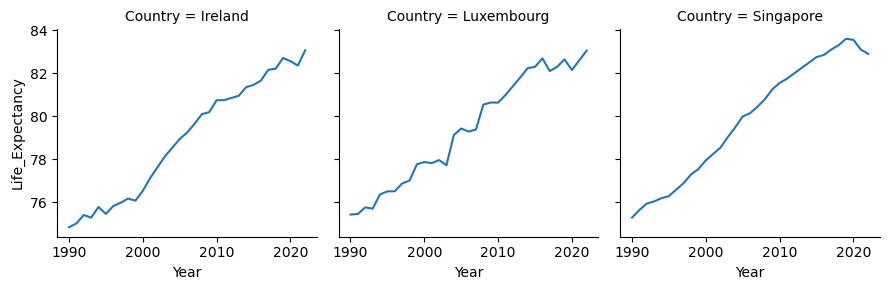

In [12]:
# CREATE FACETGRID
le_plot(country_list=["Ireland", "Singapore", "Luxembourg"])

## Part 4: Combine your `get_top_countries` and `le_plot` function together in a code cell so that you can quickly explore over a few different year and top_n values.

In [13]:
def get_top_countries(year: int, top_n: int = 3) -> "DataFrame":
    """This function finds the countries with the top highest GDP per capita given a number of countries and a year.
    
    Params:
        year (int): Specified year to filter
        top_n (int): Number of countries to return

    Returns:
        DataFrame
    """
    return gdp_le[gdp_le['Year'] == year].nlargest(top_n, 'GDP_Per_Capita')

def le_plot(country_list: list[str]) -> None:
    """This function creates a FacetGrid of life expectancy of changes over time given a list of countries.
    
    Params:
        country_list (list[str]): List of countries
    
    Returns:
        None
    """
    top_countries_df = gdp_le[gdp_le['Country'].isin(country_list)]

    g = sns.FacetGrid(data=top_countries_df, col='Country')
    g.map(sns.lineplot, 'Year', 'Life_Expectancy');

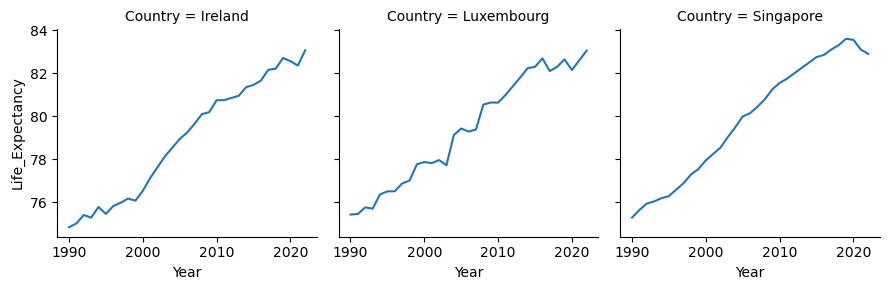

In [14]:
# GET LIST OF COUNTRIES
countries = get_top_countries(year=2021)['Country'].values

# CREATE FACETGRID
le_plot(country_list=countries)

## Part 5: You can add a title to a FacetGrid by using the suptitle method. See the following example:

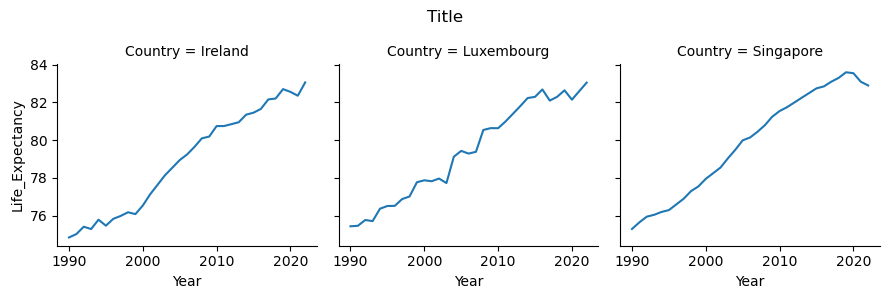

In [15]:
top_countries_df = gdp_le[gdp_le['Country'].isin(['Luxembourg', 'Singapore', 'Ireland'])]

g = sns.FacetGrid(data=top_countries_df, col='Country')
g.map(sns.lineplot, 'Year', 'Life_Expectancy')
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Title');

Modify your le_plot code to allow for an optional title. If title text is provided it, should use the subplots_adjust and suptitle methods to add the supplied text as a title. Hint: You can make the default for the title parameter None.

In [16]:
def get_top_countries(year: int, top_n: int = 3) -> "DataFrame":
    """This function finds the countries with the top highest GDP per capita given a number of countries and a year.
    
    Params:
        year (int): Specified year to filter
        top_n (int): Number of countries to return

    Returns:
        DataFrame
    """
    return gdp_le[gdp_le['Year'] == year].nlargest(top_n, 'GDP_Per_Capita')

def le_plot(country_list: list[str], title: str = None) -> None:
    """This function creates a FacetGrid of life expectancy of changes over time given a list of countries.
    
    Params:
        country_list (list[str]): List of countries
        title (str): Optional title

    Returns:
        None
    """
    top_countries_df = gdp_le[gdp_le['Country'].isin(country_list)]

    g = sns.FacetGrid(data=top_countries_df, col='Country')
    g.map(sns.lineplot, 'Year', 'Life_Expectancy')

    if title:
        g.fig.subplots_adjust(top=0.8)
        g.fig.suptitle(title)
    ;

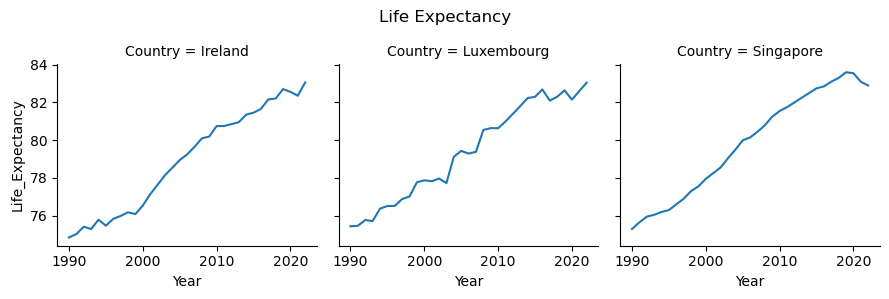

In [17]:
# GET LIST OF COUNTRIES
countries = get_top_countries(year=2021)['Country'].values

# CREATE FACETGRID WITH TITLE
le_plot(country_list=countries, title="Life Expectancy")

## Part 6: Finally, use the `get_top_countries` function together with the `le_plot` function in a cell so that you can quickly explore over a few different year and top_n values.
The resulting plots should include the year and top_n value, so that, for example, if you are looking at the top 3 countries for 2021, the title is "Top 3 Countries by GDP Per Capita for 2021". Can you make the title work when only the top country is selected?

In [18]:
def get_top_countries(year: int, top_n: int = 3) -> "DataFrame":
    """This function finds the countries with the top highest GDP per capita given a number of countries and a year.
    
    Params:
        year (int): Specified year to filter
        top_n (int): Number of countries to return

    Returns:
        DataFrame
    """
    return gdp_le[gdp_le['Year'] == year].nlargest(top_n, 'GDP_Per_Capita')

def le_plot(country_list: list[str], title: str = None) -> None:
    """This function creates a FacetGrid of life expectancy of changes over time given a list of countries.
    
    Params:
        country_list (list[str]): List of countries
        title (str): Optional title

    Returns:
        None
    """
    top_countries_df = gdp_le[gdp_le['Country'].isin(country_list)]

    g = sns.FacetGrid(data=top_countries_df, col='Country')
    g.map(sns.lineplot, 'Year', 'Life_Expectancy')

    if title:
        g.fig.subplots_adjust(top=0.8)
        g.fig.suptitle(title)
    ;

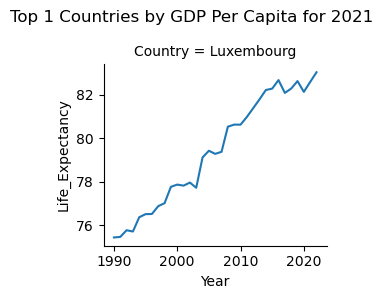

In [20]:
# SET ARGS
year = 2021

# GET DATAFRAME
countries_df = get_top_countries(year=year, top_n=1)

# SET ARGS
countries = countries_df['Country'].values
title = f"Top {len(countries)} Countries by GDP Per Capita for {year}"

# CREATE FACETGRID
le_plot(country_list=countries, title=title)